In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# Load data

# HO
df = pd.read_csv(r'...\GitHub\review_justice-patterns\Data\shape_submission_results_default_version_1_1_0_rc2_20241114.csv')
regions_df = pd.read_excel(r'...\GitHub\review_justice-patterns\Data\region_classification.xlsx')


# Wrangle data
# Retain relevant columns

regions_df = regions_df[['ISO', 'region_r10_db']]
df_joint = pd.merge(df, regions_df,
                     how='left', left_on='iso', right_on='ISO')


In [3]:
# check whether pop_mil is the same across models
(
    df_joint.groupby(['variable', 'scenario', 'model', 'region_r10_db'])
    .apply(lambda group: np.sum(group['pop_mil']))
    .reset_index(name='pop_mil_sum')
    .query("scenario in ['SSP2-1p5C', 'SSP2-NPi']")  # Proper filtering method

)

C:\Users\schei\AppData\Local\Temp\ipykernel_15200\3658395271.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: np.sum(group['pop_mil']))


,variable,scenario,model,region_r10_db,pop_mil_sum
260,Final Energy|Industry,SSP2-1p5C,IMAGE 3.3,Countries of Latin America and the Caribbean,8485.710282
261,Final Energy|Industry,SSP2-1p5C,IMAGE 3.3,Countries of South Asia; primarily India,28251.045782
262,Final Energy|Industry,SSP2-1p5C,IMAGE 3.3,Countries of Sub-Saharan Africa,27478.806219
263,Final Energy|Industry,SSP2-1p5C,IMAGE 3.3,Countries of centrally-planned Asia; primarily...,16669.347942
264,Final Energy|Industry,SSP2-1p5C,IMAGE 3.3,"Countries of the Middle East; Iran, Iraq, Isra...",3531.047777
...,...,...,...,...,...
1045,Final Energy|Transportation,SSP2-NPi,REMIND-MAgPIE 3.2-4.6,"Eastern and Western Europe (i.e., the EU28)",8967.919220
1046,Final Energy|Transportation,SSP2-NPi,REMIND-MAgPIE 3.2-4.6,North America; primarily the United States of ...,6090.680380
1047,Final Energy|Transportation,SSP2-NPi,REMIND-MAgPIE 3.2-4.6,Other countries of Asia,10378.366842
1048,Final Energy|Transportation,SSP2-NPi,REMIND-MAgPIE 3.2-4.6,Pacific OECD,2024.301424


In [3]:
# Limit data further
df_joint = df_joint.loc[
    # Select relevant variables
    (df_joint['variable'].isin(["Final Energy|Residential and Commercial", "Final Energy|Transportation"])) &
    # Focus on scaling factor of the scenario SSP2-1p5C
    (df_joint['scenario'].isin(['SSP2-1p5C', 'SSP2-NPi'])) &
    # Focus on the year 2050
    (df_joint['year'].isin([2050]))
]

#to compare results to other scenarios
df_test = df_joint.loc[
    (df_joint['variable'].isin(["Final Energy|Residential and Commercial", "Final Energy|Transportation"])) &
    (df_joint['year'].isin([2050]))
]

In [10]:
df['scenario'].unique()

array(['SDP_EI-1p5C', 'SDP_EI-1p5C-CCimp', 'SDP_EI-low1p5C',
       'SDP_MC-1p5C', 'SDP_MC-1p5C-CCimp', 'SDP_MC-low1p5C',
       'SDP_RC-1p5C', 'SDP_RC-1p5C-CCimp', 'SDP_RC-low1p5C', 'SSP1-1p5C',
       'SSP1-low1p5C', 'SSP2-1p5C', 'SSP2-1p5C-CCimp', 'SSP2-low1p5C',
       'SSP1-1p5C-CCimp', 'SDP_EI-NPi', 'SDP_MC-NPi', 'SDP_RC-NPi',
       'SSP1-NDC', 'SSP2-NDC', 'SSP1-NPi', 'SSP2-NPi', 'SSP2-NPi-CCimp',
       'SSP1-NPi-CCimp'], dtype=object)

In [43]:
# Calculate the average regional dle threshold for each model-scenario-variable combination
# must be seperated by model because models assume different populations, leading to different weights.
mapping = (
    df_joint.groupby(['variable', 'model', 'scenario', 'region_r10_db'])[['dle.threshold.adjusted', 'pop_mil']]
    .apply(lambda group: np.average(group['dle.threshold.adjusted'], weights=group['pop_mil']))
    .reset_index(name='weighted_avg_dle_threshold_adjusted')
)

# Calculate average across models
mapping = (
    mapping.groupby(['variable', 'scenario', 'region_r10_db'])[['weighted_avg_dle_threshold_adjusted']]
    .mean()
    .reset_index()
    #add a column that holds the unit
    .assign(unit='GJ/cap/yr')
    )

#Rename region_r10_db to region
mapping.rename(columns={'region_r10_db': 'region'}, inplace=True)




In [52]:
# Export to CSV
mapping.to_csv('dle_thresholds.csv', index=False)

c:\Users\scheifinger\AppData\Local\anaconda3\envs\pyam\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)


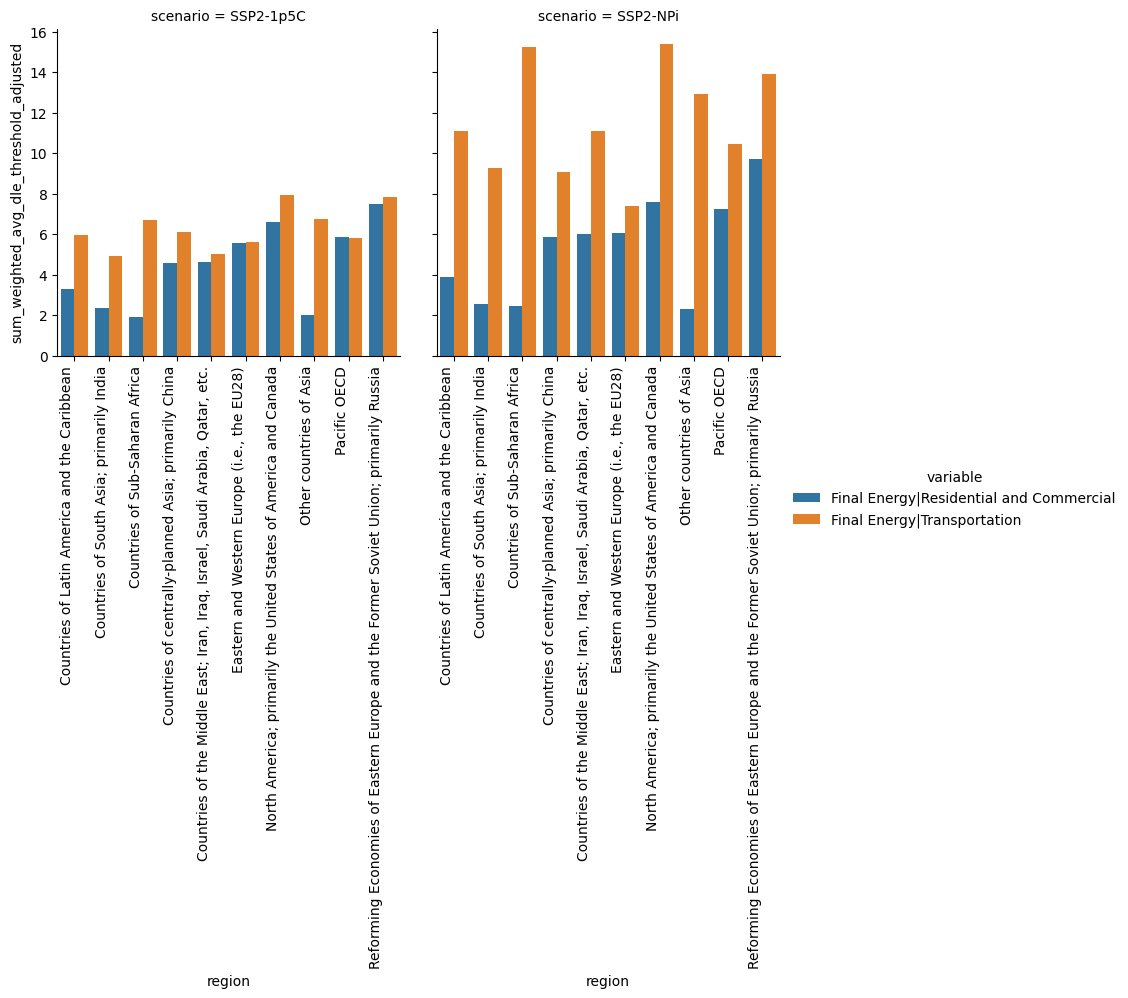

In [48]:
#plt.figure(figsize=(15, 6))
barplot = sns.catplot(data=mapping, x="region", 
                      y="sum_weighted_avg_dle_threshold_adjusted", hue="variable",
                      kind="bar", col = 'scenario',
                          height=4,  # Controls subplot height
                          aspect=1) 

# Rotate x-axis labels for each subplot
for ax in barplot.axes.flat:  
    ax.set_xticklabels(mapping['region'].unique(), rotation=90, ha='right')


plt.show()

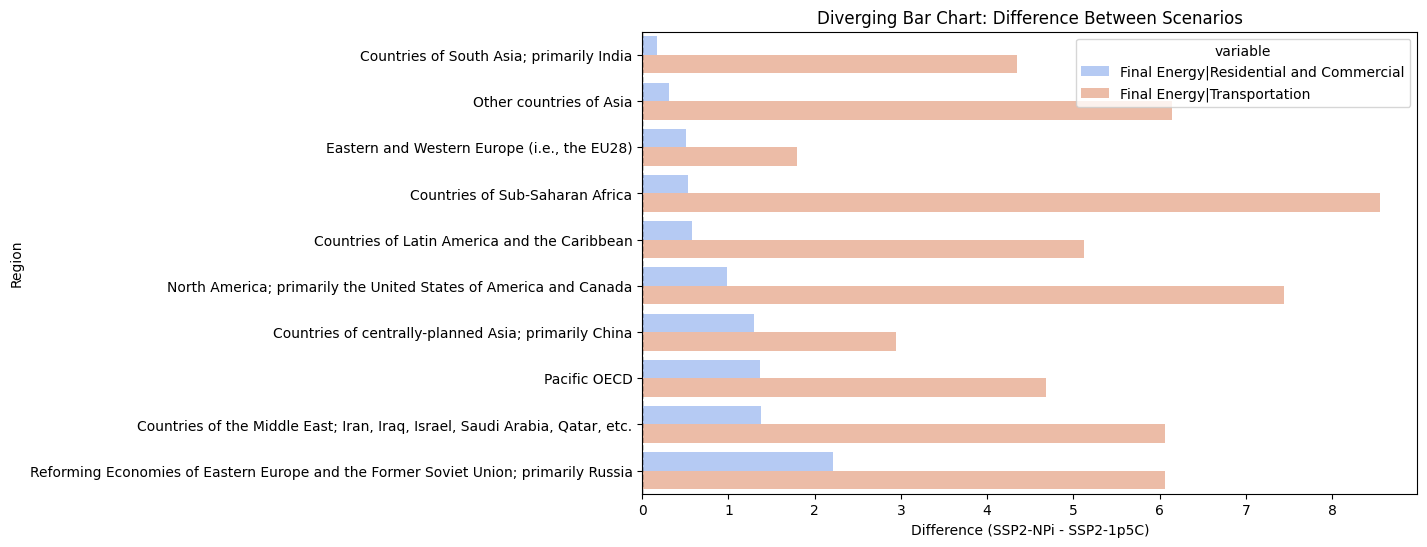

In [50]:
diff_df = mapping.pivot_table(
    index=["region", "variable"], 
    columns="scenario", 
    values="sum_weighted_avg_dle_threshold_adjusted"
).reset_index()

# Compute the difference between the two scenarios
diff_df["difference"] = diff_df["SSP2-NPi"] - diff_df["SSP2-1p5C"]


diff_df = diff_df.sort_values("difference", ascending=True)

# Create a diverging bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=diff_df, 
    x="difference", 
    y="region", 
    hue="variable",  # Color by variable
    palette="coolwarm",  # Diverging color scheme
)

# Add a vertical line at 0 for reference
plt.axvline(0, color="black", linewidth=1, linestyle="--")

plt.xlabel("Difference (SSP2-NPi - SSP2-1p5C)")
plt.ylabel("Region")
plt.title("Diverging Bar Chart: Difference Between Scenarios")

plt.show()

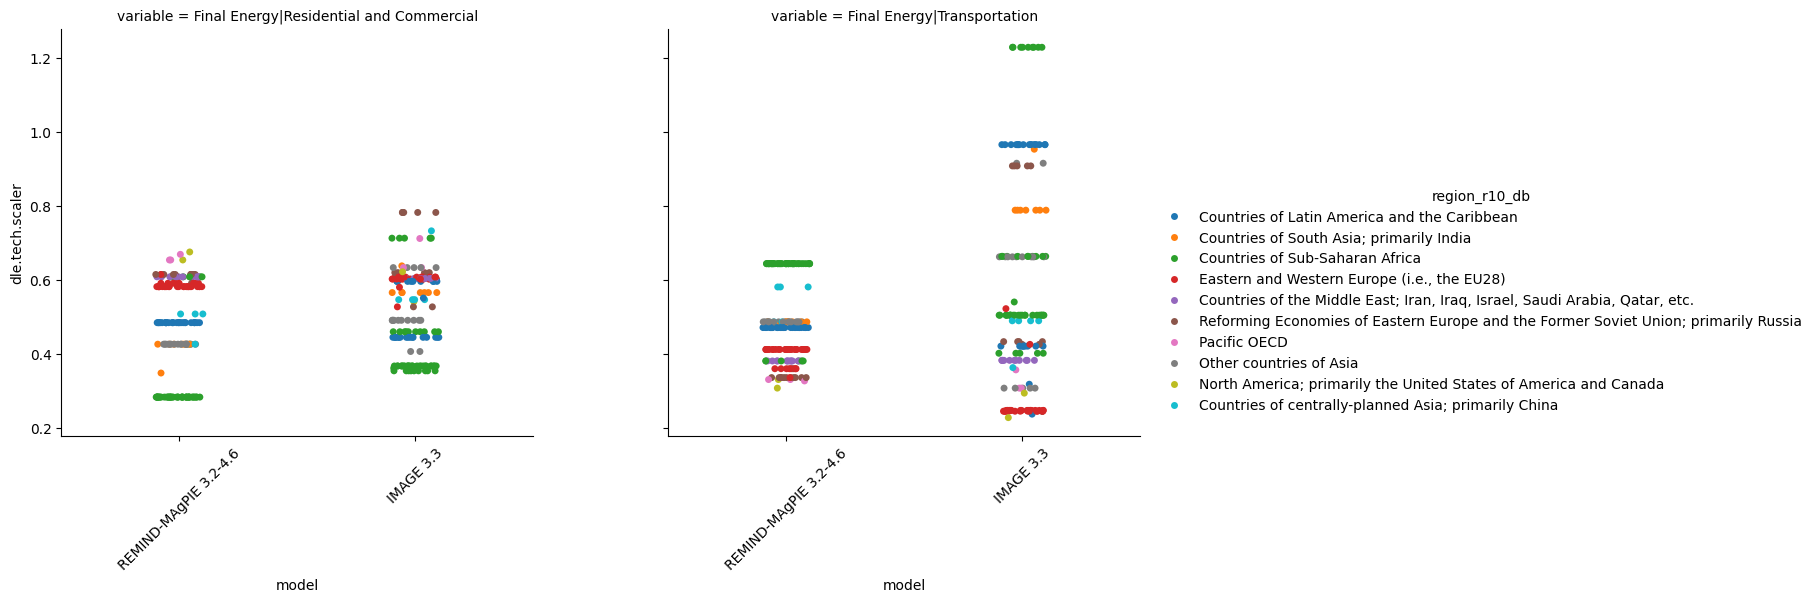

In [34]:
g = sns.catplot(
    data=df_test,
    x="model", y="dle.tech.scaler", hue="region_r10_db",
    col="variable",  # Creates facets for each scenario
    kind="strip",      # Boxplot (can also use "violin", "bar", etc.)
    height=5, aspect=1.2,  # Adjust figure size
    col_wrap=2
)

g.set_xticklabels(rotation=45)  # Rotate x-axis labels for readability
plt.show()

In [15]:
sdps = pd.merge(df, regions_df,
                     how='left', left_on='iso', right_on='ISO')

sdps = sdps.loc[
    # Select relevant variables
    (sdps['variable'].isin(["Final Energy|Residential and Commercial", "Final Energy|Transportation"])) &
    # Focus on scaling factor of the scenario SSP2-1p5C
    (sdps['scenario'].isin(['SDP_EI-1p5C', 'SDP_MC-1p5C', 'SDP_RC-1p5C', 'SSP2-NPi'])) & 
    # Focus on the year 2050
    (sdps['year'].isin([2050]))
]


sdp_mapping = (
    sdps.groupby(['variable', 'model', 'scenario', 'region_r10_db'])[['energy.per.capita.uncorrected', 'pop_mil']]
    .apply(lambda group: np.average(group['energy.per.capita.uncorrected'], weights=group['pop_mil']))
    .reset_index(name='weighted_avg_energy_per_capita_uncorrected')
)


# Calculate average across models
sdp_mapping = (
    sdp_mapping.groupby(['variable', 'scenario', 'region_r10_db'])[['weighted_avg_energy_per_capita_uncorrected']]
    .mean()
    .reset_index()
    #add a column that holds the unit
    .assign(unit='GJ/cap/yr')
    )

#Rename region_r10_db to region
sdp_mapping.rename(columns={'region_r10_db': 'region'}, inplace=True)

In [18]:
sdp_mapping['scenario'].unique()

array(['SDP_EI-1p5C', 'SDP_MC-1p5C', 'SDP_RC-1p5C', 'SSP2-NPi'],
      dtype=object)

In [19]:
# Export to CSV
sdp_mapping.to_csv('sdp_thresholds.csv', index=False)

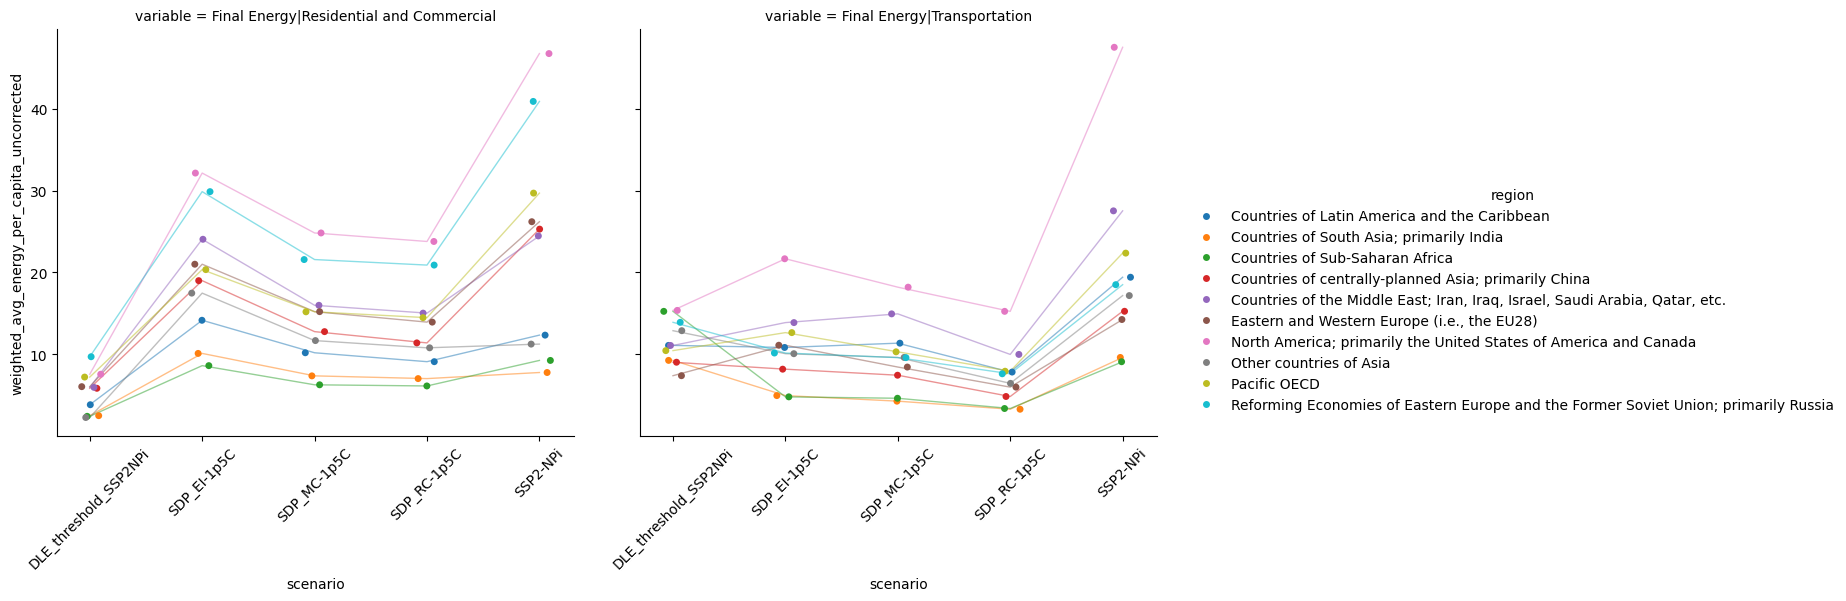

In [16]:
# Residential and Commercial DLE thresholds
housing_dle = {
    "Countries of Latin America and the Caribbean": 3.869698,
    "Countries of South Asia; primarily India": 2.535755,
    "Countries of Sub-Saharan Africa": 2.454166,
    "Countries of centrally-planned Asia; primarily China": 5.874153,
    "Countries of the Middle East; Iran, Iraq, Israel, Saudi Arabia, Qatar, etc.": 5.988561,
    "Eastern and Western Europe (i.e., the EU28)": 6.074608,
    "North America; primarily the United States of America and Canada": 7.588831,
    "Other countries of Asia": 2.310409,
    "Pacific OECD": 7.243551,
    "Reforming Economies of Eastern Europe and the Former Soviet Union; primarily Russia": 9.724514
}

# Transportation DLE thresholds
transportation_dle = {
    "Countries of Latin America and the Caribbean": 11.105045,
    "Countries of South Asia; primarily India": 9.277746,
    "Countries of Sub-Saharan Africa": 15.259728,
    "Countries of centrally-planned Asia; primarily China": 9.054579,
    "Countries of the Middle East; Iran, Iraq, Israel, Saudi Arabia, Qatar, etc.": 11.098367,
    "Eastern and Western Europe (i.e., the EU28)": 7.411672,
    "North America; primarily the United States of America and Canada": 15.374765,
    "Other countries of Asia": 12.901151,
    "Pacific OECD": 10.469697,
    "Reforming Economies of Eastern Europe and the Former Soviet Union; primarily Russia": 13.920760
}

# Convert to DataFrames
df_hous = pd.DataFrame(list(housing_dle.items()), columns=["region", "weighted_avg_energy_per_capita_uncorrected"])
df_hous["variable"] = "Final Energy|Residential and Commercial"
df_hous['scenario'] = "DLE_threshold_SSP2NPi"

df_trans = pd.DataFrame(list(transportation_dle.items()), columns=["region", "weighted_avg_energy_per_capita_uncorrected"])
df_trans["variable"] = "Final Energy|Transportation"
df_trans['scenario'] = "DLE_threshold_SSP2NPi"

# Combine both
dle_df = pd.concat([df_hous, df_trans], ignore_index=True)
# Combine with sdp_mapping
sdp_combined = pd.concat([sdp_mapping, dle_df], ignore_index=True)
sdp_combined["scenario"] = pd.Categorical(
    sdp_combined["scenario"],
    categories=['DLE_threshold_SSP2NPi', 'SDP_EI-1p5C', 'SDP_MC-1p5C', 'SDP_RC-1p5C', 'SSP2-NPi'],  # your desired order
    ordered=True
)

g = sns.catplot(
    data=sdp_combined,
    x="scenario", y="weighted_avg_energy_per_capita_uncorrected", hue="region",
    col="variable",  # Creates facets for each scenario
    kind="strip",      # Boxplot (can also use "violin", "bar", etc.)
    height=5, aspect=1.2,  # Adjust figure size
    #col_wrap=2
)

# Now map line plots to connect points of the same region
def connect_points(data, **kwargs):
    # Sort by scenario if needed
    data = data.sort_values("scenario")
    
    for region, region_data in data.groupby("region"):
        plt.plot(
            region_data["scenario"],
            region_data["weighted_avg_energy_per_capita_uncorrected"],
            label=region,
            alpha=0.5,
            linewidth=1,
        )

# Overlay the connecting lines
g.map_dataframe(connect_points)

g.set_xticklabels(rotation=45)  # Rotate x-axis labels for readability
plt.show()